In [1]:
#CHIAMATA API
import requests
import pandas as pd
import io

url = "https://esploradati.istat.it/SDMXWS/rest/data/41_983"

#Imposto l'header per ricevere un CSV invece di un XML
headers = {
    'Accept': 'application/vnd.sdmx.data+csv;version=1.0.0'
}

#Effettuo la chiamata API
response = requests.get(url, headers=headers)

if response.status_code == 200:
    # Trasformo il contenuto della risposta in un DataFrame
    df_istat = pd.read_csv(io.StringIO(response.text))
    print("Dati caricati con successo!")
    print(df_istat.head())
else:
    print(f"Errore nella richiesta: {response.status_code}")

Dati caricati con successo!
          DATAFLOW FREQ  REF_AREA DATA_TYPE RESULT  TIME_PERIOD  OBS_VALUE  \
0  IT1:41_983(1.0)    A      1001   KILLINJ      F         2001         10   
1  IT1:41_983(1.0)    A      1001   KILLINJ      F         2002         10   
2  IT1:41_983(1.0)    A      1001   KILLINJ      F         2003          7   
3  IT1:41_983(1.0)    A      1001   KILLINJ      F         2004         13   
4  IT1:41_983(1.0)    A      1001   KILLINJ      F         2005          2   

   OBS_STATUS  NOTE_DS  NOTE_REF_AREA  NOTE_DATA_TYPE  NOTE_RESULT  \
0         NaN      NaN            NaN             NaN          NaN   
1         NaN      NaN            NaN             NaN          NaN   
2         NaN      NaN            NaN             NaN          NaN   
3         NaN      NaN            NaN             NaN          NaN   
4         NaN      NaN            NaN             NaN          NaN   

   NOTE_TIME_PERIOD  BASE_PER  UNIT_MEAS  UNIT_MULT  
0               NaN       Na

In [ ]:
#Carico il Dataset in formato CSV e le librerie utili
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_istat=pd.read_csv('incidenti_istat_backup.csv', sep=';')
display(df_istat.head())



,DATAFLOW,FREQ,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,OBS_STATUS,NOTE_DS,NOTE_REF_AREA,NOTE_DATA_TYPE,NOTE_RESULT,NOTE_TIME_PERIOD,BASE_PER,UNIT_MEAS,UNIT_MULT
0,IT1:41_983(1.0),A,1001,KILLINJ,F,2001,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IT1:41_983(1.0),A,1001,KILLINJ,F,2002,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IT1:41_983(1.0),A,1001,KILLINJ,F,2003,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IT1:41_983(1.0),A,1001,KILLINJ,F,2004,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IT1:41_983(1.0),A,1001,KILLINJ,F,2005,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Controllo i valori unici che ci sono per ogni colonna
for column in df_istat.columns:
    valori_unici = df_istat[column].unique()
    print(f"Colonna: {column}")
    print(valori_unici)
    print("\n")




Colonna: DATAFLOW
['IT1:41_983(1.0)']


Colonna: FREQ
['A']


Colonna: REF_AREA
[  1001   1002   1003 ... 111105 111106 111107]


Colonna: DATA_TYPE
['KILLINJ' 'ROADACC']


Colonna: RESULT
['F' 'M' '9']


Colonna: TIME_PERIOD
[2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014
 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]


Colonna: OBS_VALUE
[  10    7   13 ... 1081  880  969]


Colonna: OBS_STATUS
[nan]


Colonna: NOTE_DS
[nan]


Colonna: NOTE_REF_AREA
[nan]


Colonna: NOTE_DATA_TYPE
[nan]


Colonna: NOTE_RESULT
[nan]


Colonna: NOTE_TIME_PERIOD
[nan]


Colonna: BASE_PER
[nan]


Colonna: UNIT_MEAS
[nan]


Colonna: UNIT_MULT
[nan]




Posso osservare che il dataset contiene colonne interamente nulle. Le elimino in quanto non contengono informazioni per l'analisi che voglio condurre.

In [ ]:
df_istat = df_istat.dropna(axis=1, how='all')
print(df_istat)



               DATAFLOW FREQ  REF_AREA DATA_TYPE RESULT  TIME_PERIOD  \
0       IT1:41_983(1.0)    A      1001   KILLINJ      F         2001   
1       IT1:41_983(1.0)    A      1001   KILLINJ      F         2002   
2       IT1:41_983(1.0)    A      1001   KILLINJ      F         2003   
3       IT1:41_983(1.0)    A      1001   KILLINJ      F         2004   
4       IT1:41_983(1.0)    A      1001   KILLINJ      F         2005   
...                 ...  ...       ...       ...    ...          ...   
573547  IT1:41_983(1.0)    A    111107   ROADACC      9         2020   
573548  IT1:41_983(1.0)    A    111107   ROADACC      9         2021   
573549  IT1:41_983(1.0)    A    111107   ROADACC      9         2022   
573550  IT1:41_983(1.0)    A    111107   ROADACC      9         2023   
573551  IT1:41_983(1.0)    A    111107   ROADACC      9         2024   

        OBS_VALUE  
0              10  
1              10  
2               7  
3              13  
4               2  
...           .

In [ ]:
#Elimino le colonne che non hanno rilevanza statistica per l'analisi che voglio condurre e rinomino le colonne utili con nomi comprensibili
df_istat_pulito=df_istat.drop(columns=['DATAFLOW','FREQ','DATA_TYPE'])

mapping_colonne = {
    'REF_AREA': 'Codice_Comune',
    'TIME_PERIOD': 'Anno',
    'OBS_VALUE': 'Conteggio_Eventi',
    'RESULT': 'Categoria'
}

df_istat_pulito.rename(columns=mapping_colonne, inplace=True)

print(df_istat_pulito.head())







   Codice_Comune Categoria  Anno  Conteggio_Eventi
0           1001         F  2001                10
1           1001         F  2002                10
2           1001         F  2003                 7
3           1001         F  2004                13
4           1001         F  2005                 2


Nel dataset originale ISTAT ogni singola riga conteneva un solo dato alla volta. Applico quindi una tabella pivot, in modo che ogni singola riga rappresenta ogni singolo comune in ogni singolo anno

In [ ]:
df_istat_pulito_pivot = df_istat_pulito.pivot_table(index=['Anno', 'Codice_Comune'],
                         columns='Categoria',
                         values='Conteggio_Eventi').reset_index()





In [ ]:
#Elimino tutte le righe che hanno almeno un NaN
df_istat_pulito_pivot1 = df_istat_pulito_pivot.dropna()


#Aggiungo la colonna di persone totali coinvolte e rinomino le colonne in modo comprensibile
df_istat_pulito_pivot1['Totale_Morti_Feriti'] = df_istat_pulito_pivot1['M'] + df_istat_pulito_pivot1['F']
df_istat_pulito_pivot1.columns = ['Anno', 'Codice_Comune', 'Numero_Incidenti', 'Numero_Feriti', 'Numero_Morti','Numero_Totale_Morti_Feriti']
display(df_istat_pulito_pivot1)

#Controllo di che tipo sono le varie colonne
print(df_istat_pulito_pivot1.dtypes)

#Trasformo la colonna anno, il numero di incidenti, il numero dei feriti, il numero dei morti e il numero totale di morti e feriti in numeri interi
df_istat_pulito_pivot1[['Anno','Numero_Incidenti','Numero_Feriti', 'Numero_Morti', 'Numero_Totale_Morti_Feriti']] = df_istat_pulito_pivot1[['Anno','Numero_Incidenti','Numero_Feriti', 'Numero_Morti', 'Numero_Totale_Morti_Feriti']].astype(int)
display(df_istat_pulito_pivot1.head())
print(df_istat_pulito_pivot1.dtypes)

,Anno,Codice_Comune,Numero_Incidenti,Numero_Feriti,Numero_Morti,Numero_Totale_Morti_Feriti
0,2001,1001,5.0,10.0,0.0,10.0
1,2001,1002,25.0,48.0,0.0,48.0
2,2001,1003,0.0,0.0,0.0,0.0
3,2001,1004,5.0,6.0,1.0,7.0
4,2001,1005,3.0,3.0,4.0,7.0
...,...,...,...,...,...,...
191179,2024,111103,4.0,4.0,0.0,4.0
191180,2024,111104,1.0,2.0,0.0,2.0
191181,2024,111105,11.0,18.0,1.0,19.0
191182,2024,111106,12.0,13.0,1.0,14.0


Anno                            int64
Codice_Comune                   int64
Numero_Incidenti              float64
Numero_Feriti                 float64
Numero_Morti                  float64
Numero_Totale_Morti_Feriti    float64
dtype: object


,Anno,Codice_Comune,Numero_Incidenti,Numero_Feriti,Numero_Morti,Numero_Totale_Morti_Feriti
0,2001,1001,5,10,0,10
1,2001,1002,25,48,0,48
2,2001,1003,0,0,0,0
3,2001,1004,5,6,1,7
4,2001,1005,3,3,4,7


Anno                          int64
Codice_Comune                 int64
Numero_Incidenti              int64
Numero_Feriti                 int64
Numero_Morti                  int64
Numero_Totale_Morti_Feriti    int64
dtype: object


In [ ]:
df_istat_pulito_pivot1['Codice_Comune'] = (
    df_istat_pulito_pivot1['Codice_Comune'].astype(str).str.zfill(6)
)

display(df_istat_pulito_pivot1.head())

,Anno,Codice_Comune,Numero_Incidenti,Numero_Feriti,Numero_Morti,Numero_Totale_Morti_Feriti
0,2001,001001,5,10,0,10
1,2001,001002,25,48,0,48
2,2001,001003,0,0,0,0
3,2001,001004,5,6,1,7
4,2001,001005,3,3,4,7


In [ ]:
#Filtro per il numero di incidenti>5
df_istat_filtrato = df_istat_pulito_pivot1[df_istat_pulito_pivot1['Numero_Incidenti'] > 5]

display(df_istat_filtrato)

,Anno,Codice_Comune,Numero_Incidenti,Numero_Feriti,Numero_Morti,Numero_Totale_Morti_Feriti
1,2001,001002,25,48,0,48
5,2001,001006,7,11,0,11
7,2001,001008,45,58,3,61
12,2001,001013,68,119,2,121
16,2001,001017,12,17,0,17
...,...,...,...,...,...,...
191162,2024,111078,6,10,0,10
191164,2024,111084,12,17,0,17
191174,2024,111096,13,22,0,22
191181,2024,111105,11,18,1,19


Si è scelto di filtrare per un numero di incidenti maggiore di 5 per avere una buona rappresentazione ignorando i comuni con numero di incidenti minimo.

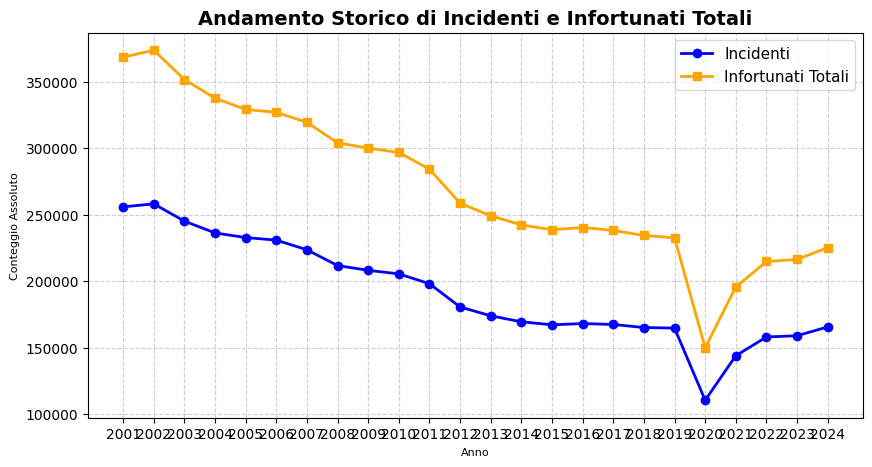

In [ ]:
#Faccio un grafico per studiare l'andamento degli incidenti totali in Italia con l'avanzare degli anni

df_trend = df_istat_filtrato.groupby('Anno')[['Numero_Incidenti', 'Numero_Totale_Morti_Feriti']].sum().reset_index()
plt.figure(figsize=(10, 5))
plt.plot(df_trend['Anno'], df_trend['Numero_Incidenti'], marker='o', label='Incidenti', color='blue', linewidth=2)
plt.plot(df_trend['Anno'], df_trend['Numero_Totale_Morti_Feriti'], marker='s', label='Infortunati Totali', color='orange', linewidth=2)
plt.title("Andamento Storico di Incidenti e Infortunati Totali", fontsize=14, fontweight='bold')
plt.xlabel("Anno", fontsize=8)
plt.ylabel("Conteggio Assoluto", fontsize=8)
plt.xticks(df_trend['Anno'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.show()

Posso osservare che fino a metà degli anni '10 c'è una diminuzione marcata degli incidenti dovuto probabilmente a miglioramenti nelle infrastrutture e nelle auto.
Osservo inoltre che nel 2020 c'è stata una diminuzione marcata degli incidenti dovuta alle restrizioni del lockdown.
Filtro perciò il dataset dal 2014 escludendo il 2020.

In [ ]:
df_dal_2014 = df_istat_filtrato[(df_istat_filtrato['Anno'] >= 2014) & (df_istat_filtrato['Anno'] != 2020)]
print("Anni presenti nel dataset filtrato:", sorted(df_dal_2014['Anno'].unique()))
print("Numero di righe rimaste:", df_dal_2014.shape[0])
display(df_dal_2014.head())

Anni presenti nel dataset filtrato: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Numero di righe rimaste: 31189


,Anno,Codice_Comune,Numero_Incidenti,Numero_Feriti,Numero_Morti,Numero_Totale_Morti_Feriti
105279,2014,001001,6,11,0,11
105280,2014,001002,8,19,1,20
105286,2014,001008,39,56,0,56
105291,2014,001013,39,58,0,58
105298,2014,001020,8,8,0,8


In [ ]:
#Inserisco il dataset per integrare con la popolazione e il nome dei comuni
import os


percorso_cartella = 'dati_popolazione/'
colonne_utili_istat = ['Codice Comune (numerico)', 'Anno (Popolazione residente)', 'Popolazione residente', 'Comune']
lista_finale = []


for nome_file in os.listdir(percorso_cartella):
    if nome_file.endswith('.csv'):

        df = pd.read_csv(os.path.join(percorso_cartella, nome_file), sep=';')

        #Filtro solo le colonne che esistono davvero nel file ISTAT
        df_pulito = df[df.columns.intersection(colonne_utili_istat)].copy()

        # Rinomino le colonne
        df_pulito.rename(columns={
            'Codice Comune (numerico)': 'Codice_Comune',
            'Anno (Popolazione residente)': 'Anno',
            'Popolazione residente': 'Popolazione'
        }, inplace=True)

        lista_finale.append(df_pulito)

# Creo il dataset unico
df_popolazione_totale = pd.concat(lista_finale, ignore_index=True)

#Pulisco i duplicati
df_popolazione_totale.drop_duplicates(subset=['Codice_Comune', 'Anno'], inplace=True)

#Elimino le righe che contengono almeno un valore nullo
df_popolazione_totale.dropna(inplace=True)

#Conto quanti anni di dati ha ogni comune
conteggio_anni = df_popolazione_totale.groupby('Codice_Comune')['Anno'].nunique()

#Prendo solo i codici che compaiono esattamente 10 volte (una per ogni anno dal 2014 al 2024, escludendo il 2020)
codici_completi = conteggio_anni[conteggio_anni == 10].index
df_popolazione_final = df_popolazione_totale[df_popolazione_totale['Codice_Comune'].isin(codici_completi)].copy()

#Verifico ora che ogni anno deve avere lo stesso identico numero di righe
print(df_popolazione_final['Anno'].value_counts().sort_index())

#Converto in stringa il Codice_Comune
df_popolazione_final['Codice_Comune'] = df_popolazione_final['Codice_Comune'].astype(str).str.zfill(6)

#Ordino per anno crescente e per Codice_Comune crescente
df_popolazione_final = df_popolazione_final.sort_values(by=['Anno', 'Codice_Comune']).reset_index(drop=True)

display(df_popolazione_final.head())

Anno
2014    7639
2015    7639
2016    7639
2017    7639
2018    7639
2019    7639
2021    7639
2022    7639
2023    7639
2024    7639
Name: count, dtype: int64


,Codice_Comune,Comune,Popolazione,Anno
0,001001,Agliè,2701,2014
1,001002,Airasca,3798,2014
2,001003,Ala di Stura,465,2014
3,001004,Albiano d'Ivrea,1754,2014
4,001006,Almese,6387,2014


In [ ]:
#Vedo se esiste Roma
roma = df_popolazione_final[df_popolazione_final['Comune'] == 'Roma']
print(roma)

      Codice_Comune Comune  Popolazione  Anno
4634         058091   Roma      2776835  2014
12273        058091   Roma      2794353  2015
19912        058091   Roma      2810118  2016
27551        058091   Roma      2815541  2017
35190        058091   Roma      2820219  2018
42829        058091   Roma      2808293  2019
50468        058091   Roma      2749031  2021
58107        058091   Roma      2755309  2022
65746        058091   Roma      2751747  2023
73385        058091   Roma      2747290  2024


In [ ]:
# Unisco df_dal_2014 (dati incidenti filtrati per anno) con df_popolazione_final (dati popolazione)
# per aggiungere la colonna 'Popolazione' ai dati degli incidenti.
# Uso 'left' merge per mantenere tutti gli incidenti dal 2014 e aggiungere la popolazione corrispondente.
df_incidenti_con_popolazione = pd.merge(
    df_dal_2014,
    df_popolazione_final[['Anno', 'Codice_Comune', 'Comune','Popolazione']],
    on=['Anno', 'Codice_Comune'],
    how='left'
)

# Filtro ora il dataframe combinato per mantenere solo le righe dove la Popolazione è maggiore di 5000 per eliminare i piccoli comuni
df_incidenti_filtrati_popolazione = df_incidenti_con_popolazione[
    df_incidenti_con_popolazione['Popolazione'] > 5000
].copy()

# Visualizziamo le prime righe del dataframe risultante
display(df_incidenti_filtrati_popolazione.head())


,Anno,Codice_Comune,Numero_Incidenti,Numero_Feriti,Numero_Morti,Numero_Totale_Morti_Feriti,Comune,Popolazione
2,2014,001008,39,56,0,56,Alpignano,17370.0
3,2014,001013,39,58,0,58,Avigliana,12445.0
5,2014,001024,52,71,1,72,Beinasco,18213.0
7,2014,001028,24,36,0,36,Borgaro Torinese,13424.0
8,2014,001034,14,18,0,18,Brandizzo,8609.0


In [ ]:
#Vedo se ci sono Roma, Torino, Milano ecc
roma = df_incidenti_filtrati_popolazione[df_incidenti_filtrati_popolazione['Comune'] == 'Roma']
print(roma)

       Anno Codice_Comune  Numero_Incidenti  Numero_Feriti  Numero_Morti  \
2059   2014        058091             13501          17667           154   
5234   2015        058091             13128          17153           173   
8355   2016        058091             13241          17306           140   
11483  2017        058091             12886          16812           129   
14593  2018        058091             11995          15551           148   
17773  2019        058091             12271          15919           131   
20749  2021        058091             11129          13862           121   
23795  2022        058091             13181          16618           150   
26889  2023        058091             12817          16023           154   
30039  2024        058091             13924          17196           134   

       Numero_Totale_Morti_Feriti Comune  Popolazione  
2059                        17821   Roma    2776835.0  
5234                        17326   Roma    2794353

In [ ]:
#Aggiungo una colonna che dice il tasso di incidenti ogni mille abitanti
df_incidenti_filtrati_popolazione['Tasso_Incidenti'] = (
    df_incidenti_filtrati_popolazione['Numero_Incidenti'] / df_incidenti_filtrati_popolazione['Popolazione'] * 1000
)

#Trasformo la Popolazione in un numero intero
df_incidenti_filtrati_popolazione['Popolazione'] = df_incidenti_filtrati_popolazione['Popolazione'].astype(int)

In [ ]:
display(df_incidenti_filtrati_popolazione.head())

,Anno,Codice_Comune,Numero_Incidenti,Numero_Feriti,Numero_Morti,Numero_Totale_Morti_Feriti,Comune,Popolazione,Tasso_Incidenti
2,2014,001008,39,56,0,56,Alpignano,17370,2.245250
3,2014,001013,39,58,0,58,Avigliana,12445,3.133789
5,2014,001024,52,71,1,72,Beinasco,18213,2.855103
7,2014,001028,24,36,0,36,Borgaro Torinese,13424,1.787843
8,2014,001034,14,18,0,18,Brandizzo,8609,1.626205


In [ ]:
#Scarico il CSV
df_incidenti_filtrati_popolazione.to_csv('dataset_incidenti_B.csv', index=False)
from google.colab import files
files.download('dataset_incidenti_B.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>